# Classification Model

- https://docs.pytorch.org/vision/main/models.html#classification

Ask AI
> How can I initialize pretrained SqueezeNet from torchvision? I am using pytorch 2.7 and torchvision 0.22.

In [1]:
import matplotlib.pyplot as plt
import requests
import torch
import torchvision.models as models
from PIL import Image
from torchvision import transforms

| Model           | Number of Parameters |
|-----------------|---------------------|
| SqueezeNet1_1   | ~1.25M              |
| MobileNet V2    | ~3.5M               |
| ResNet18        | ~11.7M              |
| VGG16           | ~138M               |

In [2]:
# ----- Load pre-trained model (choose one by uncommenting) -----
# model_choice = "squeezenet1_1"
# model_choice = "mobilenet_v2"
model_choice = "resnet18"
# model_choice = "vgg16"

In [3]:
# Load the chosen pre-trained model from torchvision.models
if model_choice == "squeezenet1_1":
    model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)
elif model_choice == "mobilenet_v2":
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
elif model_choice == "resnet18":
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
elif model_choice == "vgg16":
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
else:
    raise Exception("Invalid model")  # Raise an error if input is invalid

# ----- Download and load ImageNet class labels from the online file -----
label_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

labels = requests.get(
    label_url
).text.splitlines()  # Split text by newlines, creating a list of label strings

# Print the selected model's name and the list of labels
print(model_choice)
print(labels)

resnet18
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamo

In [4]:
import requests  # Import the requests library for handling HTTP requests

# URL where the ImageNet class labels are stored as a plain text file
label_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

# Send a GET request to the URL and get the content as a string
labels = requests.get(
    label_url
).text.splitlines()  # Split by lines to create a list of labels

print(labels)

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 

In [5]:
from torchinfo import summary

input_size = (1, 3, 224, 224)  # (batch_size, channels, height, width)
summary(model, input_size=input_size)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

### What is `.named_parameters()` in PyTorch?
- `.named_parameters()` is a method provided by PyTorch’s nn.Module class (the base class for all models and layers in PyTorch).
- It allows you to iterate over all the parameters of your model, but with an added benefit: it gives you both the name of the parameter (as a string) and the parameter itself (as a torch.nn.Parameter object).

In [6]:
for name, param in model.named_parameters():
    print(f"Parameter name: {name}")
    print(f"Shape: {param.shape}")
    print(f"Requires grad: {param.requires_grad}")  # True if parameter will be updated
    print("-" * 50)


Parameter name: conv1.weight
Shape: torch.Size([64, 3, 7, 7])
Requires grad: True
--------------------------------------------------
Parameter name: bn1.weight
Shape: torch.Size([64])
Requires grad: True
--------------------------------------------------
Parameter name: bn1.bias
Shape: torch.Size([64])
Requires grad: True
--------------------------------------------------
Parameter name: layer1.0.conv1.weight
Shape: torch.Size([64, 64, 3, 3])
Requires grad: True
--------------------------------------------------
Parameter name: layer1.0.bn1.weight
Shape: torch.Size([64])
Requires grad: True
--------------------------------------------------
Parameter name: layer1.0.bn1.bias
Shape: torch.Size([64])
Requires grad: True
--------------------------------------------------
Parameter name: layer1.0.conv2.weight
Shape: torch.Size([64, 64, 3, 3])
Requires grad: True
--------------------------------------------------
Parameter name: layer1.0.bn2.weight
Shape: torch.Size([64])
Requires grad: True

In [7]:
# Define a sequence of preprocessing transformations for input images,
# typically used for models trained on ImageNet.
preprocess = transforms.Compose(
    [
        transforms.Resize(256),  # Resize the shortest side of the image to 256 pixels
        transforms.CenterCrop(224),  # Crop the center 224x224 region
        transforms.ToTensor(),  # Convert the PIL image to a PyTorch tensor and scale to [0, 1]
        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],  # Normalize each channel using ImageNet dataset mean
            std=[
                0.229,
                0.224,
                0.225,
            ],  # Normalize each channel using ImageNet dataset std deviation
        ),
    ]
)

### Upload image

FileUpload(value=(), accept='image/*', description='Upload')

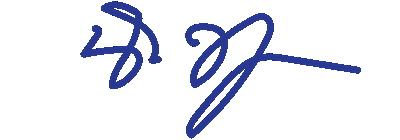

In [8]:
import io

import ipywidgets as widgets
from IPython.display import display

image_data = dict(image=None)


def on_upload_change(change):
    file_content = uploader.value[0]["content"]
    image = Image.open(io.BytesIO(file_content)).convert("RGB")
    image_data["image"] = image
    display(image)  # Show the image


uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(uploader)
uploader.observe(on_upload_change, names="value")

In [12]:
if image_data["image"] is not None:
    input_tensor = preprocess(image_data["image"])
    input_batch = input_tensor.unsqueeze(0)
    print(input_tensor.shape)

torch.Size([3, 224, 224])


### Check what actually goes into the model

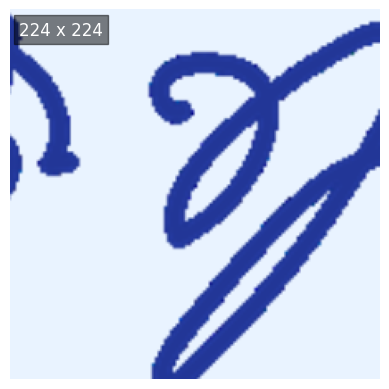

In [13]:
if image_data["image"] is not None:
    # Get the image tensor's dimensions: (channels, height, width)
    _, height, width = input_tensor.shape

    # Reorder tensor axes to (height, width, channels) for displaying with matplotlib
    img = input_tensor.permute(1, 2, 0).numpy()

    # -- Min-max normalization to scale pixel values to the [0, 1] range --
    min_val = img.min()
    max_val = img.max()
    img = (img - min_val) / (max_val - min_val)

    # Display the image without axes
    plt.imshow(img)
    plt.axis("off")

    # Overlay the image resolution on the image (top-left corner) with a background box for readability
    plt.text(
        5,
        15,
        f"{width} x {height}",
        color="white",
        bbox=dict(facecolor="black", alpha=0.5),
        fontsize=12,
    )
    plt.show()


### Prediction

In [14]:
if image_data["image"] is not None:
    # Set the model to evaluation mode (important for layers like dropout or batchnorm)
    model.eval()

    # Temporarily disable gradient calculation to speed up computation and save memory
    with torch.no_grad():
        # Forward pass: get the model's raw output (logits) for the input batch
        output = model(input_batch)

    # Apply softmax to convert logits to probabilities for the first item in the batch
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # Get the top 5 probabilities and their category indices
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    print("\n🌟 Top-5 Predictions 🌟")
    print("=" * 50)
    print(f"{'Rank':<5} {'Label':<25} {'Confidence':>10}")
    print("-" * 50)

    for i in range(top5_prob.size(0)):
        rank = i + 1
        label = labels[top5_catid[i]]
        percent = top5_prob[i].item() * 100
        print(f"{rank:<5} {label:<25} {percent:>8.2f}%")

    print("=" * 50)


🌟 Top-5 Predictions 🌟
Rank  Label                     Confidence
--------------------------------------------------
1     whistle                      20.55%
2     stopwatch                     7.40%
3     muzzle                        2.94%
4     hair slide                    2.61%
5     knot                          1.93%
